# Tips Data sets 

    We are not doing MultiNomial as it requires NLP and we havent done it yet 

In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


```
total_bill  →  numeric  →  keep
tip         →  numeric  →  keep
sex         →  Male/Female  →  encode
smoker      →  Yes/No  →  encode
day         →  Thur/Fri/Sat/Sun  →  encode
time        →  Lunch/Dinner  →  TARGET
size        →  numeric (party size)  →  keep

In [2]:
df.shape

(244, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
from collections import Counter

Counter(df["time"])

Counter({'Dinner': 176, 'Lunch': 68})

```
In Classification Always Check OutPut if its imbalaced or not 

Dinner : 176  →  72%
Lunch  :  68  →  28%

/tmp/ipykernel_31770/1573232817.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="time", data=df, palette=["steelblue", "coral"])


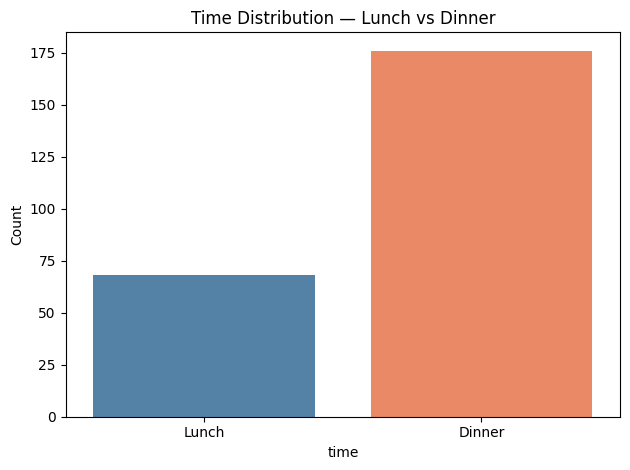

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

# target distribution
sns.countplot(x="time", data=df, palette=["steelblue", "coral"])
plt.title("Time Distribution — Lunch vs Dinner")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_31770/2905889346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="total_bill", data=df, palette=["steelblue", "coral"])


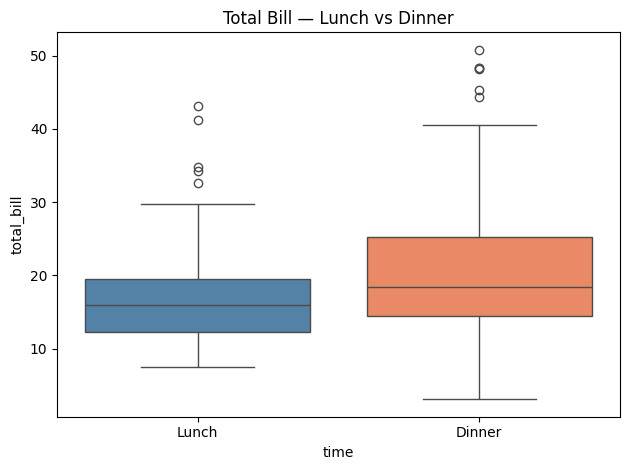

In [8]:
# total_bill by time
sns.boxplot(x="time", y="total_bill", data=df, palette=["steelblue", "coral"])
plt.title("Total Bill — Lunch vs Dinner")
plt.tight_layout()
plt.show()

/tmp/ipykernel_31770/1166114373.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="tip", data=df, palette=["steelblue", "coral"])


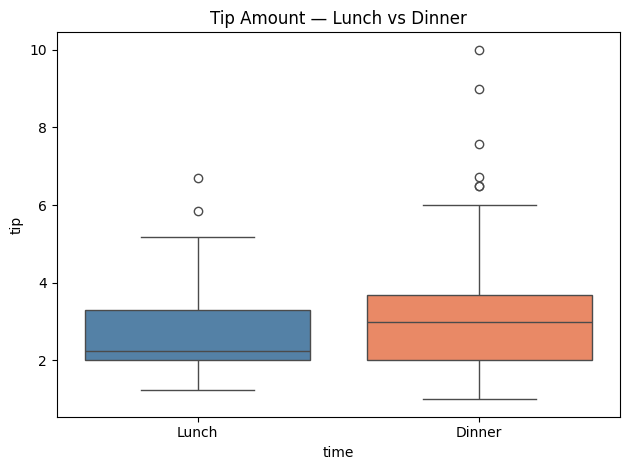

In [9]:
# tip by time
sns.boxplot(x="time", y="tip", data=df, palette=["steelblue", "coral"])
plt.title("Tip Amount — Lunch vs Dinner")
plt.tight_layout()
plt.show()

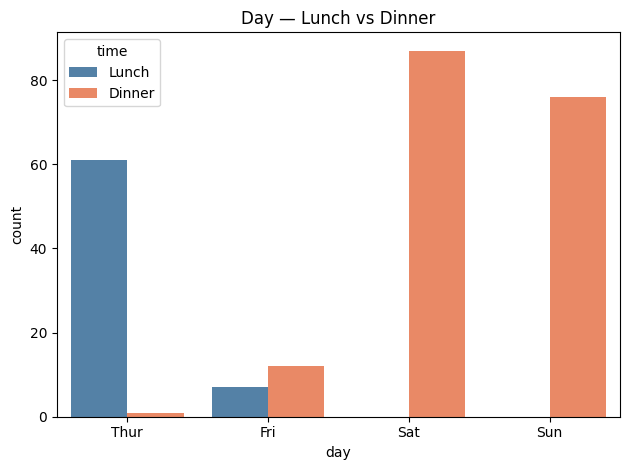

In [10]:
# day by time
sns.countplot(x="day", hue="time", data=df, palette=["steelblue", "coral"])
plt.title("Day — Lunch vs Dinner")
plt.tight_layout()
plt.show()

```
Thursday  →  61 Lunch, 1 Dinner   →  almost ALL Thursday visits are lunch
Saturday  →  0 Lunch, 87 Dinner   →  Saturday is 100% dinner
Sunday    →  0 Lunch, 76 Dinner   →  Sunday is 100% dinner
Friday    →  7 Lunch, 12 Dinner   →  mixed but mostly dinner

Day is the BEST predictor of time
If day = Sat or Sun → definitely dinner
If day = Thur → definitely lunch

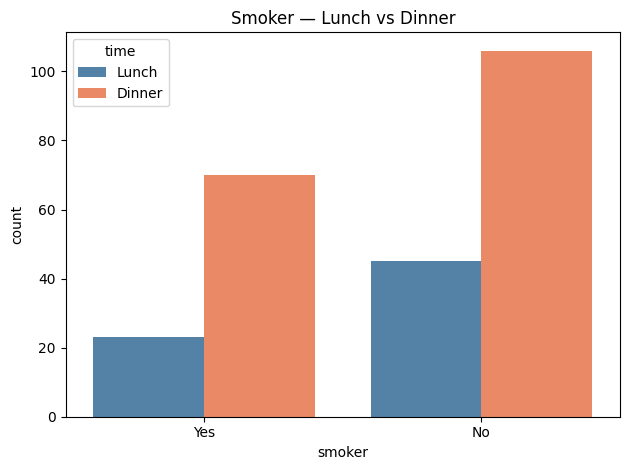

In [11]:
# smoker by time
sns.countplot(x="smoker", hue="time", data=df, palette=["steelblue", "coral"])
plt.title("Smoker — Lunch vs Dinner")
plt.tight_layout()
plt.show()

___
# Check Outlierss and Skewness
___

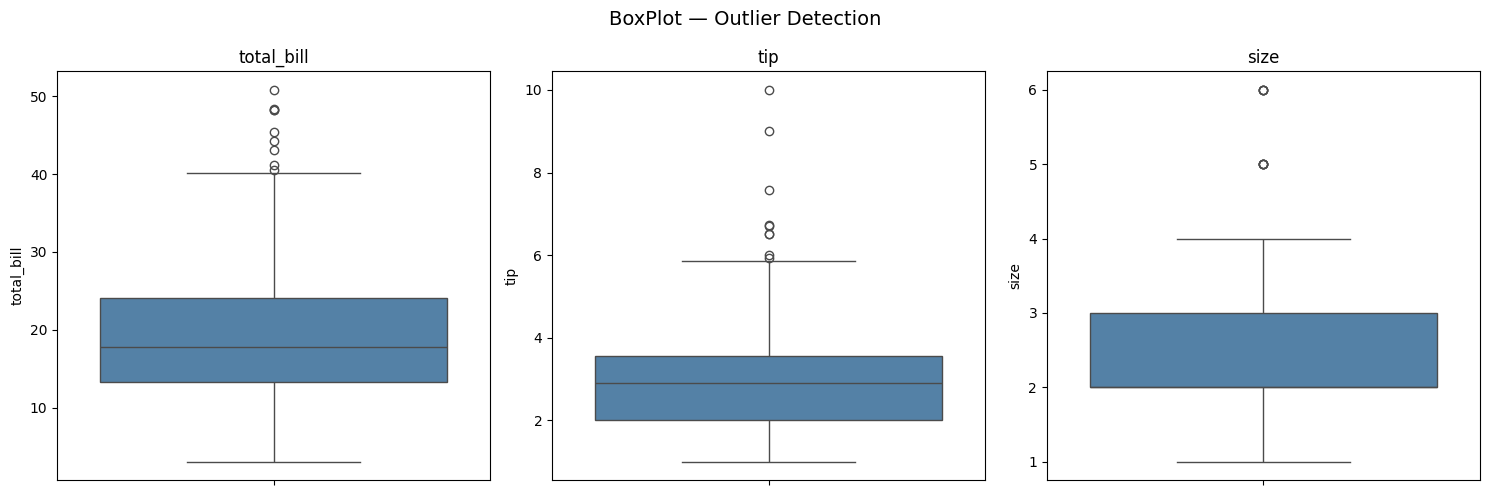

In [12]:
continuous_cols = ["total_bill", "tip", "size"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
for col in continuous_cols:
    skew = df[col].skew()
    print(f"{col:12} → skewness: {skew:.4f}  {'⚠️ skewed' if abs(skew) > 1 else '✅ ok'}")

total_bill   → skewness: 1.1332  ⚠️ skewed
tip          → skewness: 1.4655  ⚠️ skewed
size         → skewness: 1.4479  ⚠️ skewed


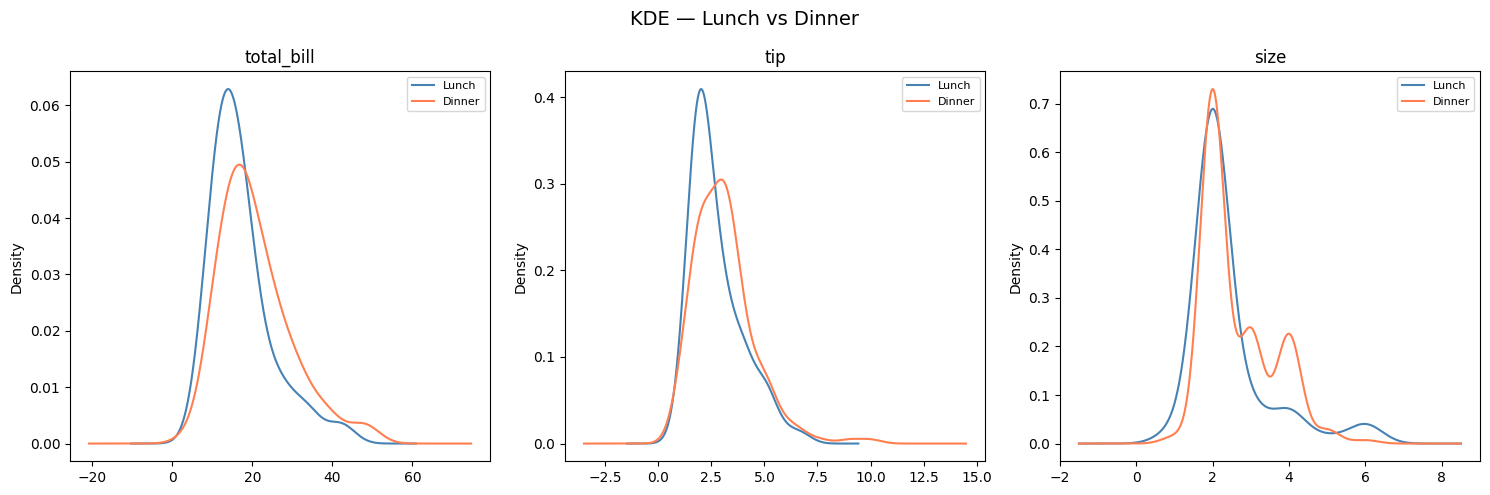

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(continuous_cols):
    df[df["time"] == "Lunch"][col].plot(kind="kde", ax=axes[i], color="steelblue", label="Lunch")
    df[df["time"] == "Dinner"][col].plot(kind="kde", ax=axes[i], color="coral", label="Dinner")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("KDE — Lunch vs Dinner", fontsize=14)
plt.tight_layout()
plt.show()

___
# Outlier remover
___

In [15]:
df_clean = df.copy()

In [16]:
outlier_cols = ["total_bill", "tip"]

print("Before:", df_clean.shape)

for col in outlier_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    before = df_clean.shape[0]
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    after = df_clean.shape[0]
    
    print(f"{col:12} → removed {before - after} rows")

df_clean.reset_index(drop=True, inplace=True)
print("After:", df_clean.shape)

Before: (244, 7)
total_bill   → removed 9 rows
tip          → removed 7 rows
After: (228, 7)


In [17]:
continuous_cols = ["total_bill", "tip", "size"]

for col in continuous_cols:
    skew = df_clean[col].skew()
    print(f"{col:12} → skewness: {skew:.4f}  {'⚠️ still skewed' if abs(skew) > 1 else '✅ ok'}")

total_bill   → skewness: 0.7625  ✅ ok
tip          → skewness: 0.5600  ✅ ok
size         → skewness: 1.5182  ⚠️ still skewed


```
size is a discrete count → 1, 2, 3, 4, 5, 6
Most people eat in pairs (size=2)
That is not a data problem — that is reality
IQR on size would remove groups of 5-6 which are real valid data points

In [18]:
# tip_percentage — how much tip relative to the bill
# captures tipping behavior better than raw tip amount
df_clean["tip_pct"] = (df_clean["tip"] / df_clean["total_bill"] * 100).round(2)

df_clean[["total_bill", "tip", "tip_pct"]].head()

,total_bill,tip,tip_pct
0,16.99,1.01,5.94
1,10.34,1.66,16.05
2,21.01,3.50,16.66
3,23.68,3.31,13.98
4,24.59,3.61,14.68


___
# X and Y spli 
___

In [19]:
X = df_clean.drop("time", axis=1)
Y = df_clean["time"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print()
print("Features:", X.columns.tolist())

X shape: (228, 7)
Y shape: (228,)

Features: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'size', 'tip_pct']


___
# Train Test Splt 
___

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = Y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

from collections import Counter
print("\ny_train:", Counter(y_train))
print("y_test :", Counter(y_test))

X_train: (182, 7)
X_test : (46, 7)

y_train: Counter({'Dinner': 131, 'Lunch': 51})
y_test : Counter({'Dinner': 33, 'Lunch': 13})


___
# Encoding
___

In [21]:
# Output features using Label Encoding
from sklearn.preprocessing import LabelEncoder

In [22]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

print("Classes:", le.classes_)
# [Dinner, Lunch] → Dinner=0, Lunch=1

Classes: ['Dinner' 'Lunch']


In [23]:
# Categorical Features in input using one hot 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [24]:
for i, col in enumerate(X_train.columns):
    print(f"{i}: {col}")

0: total_bill
1: tip
2: sex
3: smoker
4: day
5: size
6: tip_pct


```
sex    → index 2 (Male/Female)
smoker → index 3 (Yes/No)
day    → index 4 (Thur/Fri/Sat/Sun)

In [25]:
ct = ColumnTransformer(
    transformers=[
        ("OneHot", OneHotEncoder(drop="first", sparse_output=False), [2, 3, 4])
        # sex=2, smoker=3, day=4
    ],
    remainder="passthrough"
)

X_train = ct.fit_transform(X_train)
X_test  = ct.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (182, 9)
X_test  shape: (46, 9)


In [26]:
ohe_cols  = ct.named_transformers_["OneHot"].get_feature_names_out(["sex", "smoker", "day"])
pass_cols = ["total_bill", "tip", "size", "tip_pct"]

all_cols = list(ohe_cols) + pass_cols

X_train = pd.DataFrame(X_train, columns=all_cols)
X_test  = pd.DataFrame(X_test,  columns=all_cols)

print("Columns:", all_cols)
X_train.head()

Columns: ['sex_Male', 'smoker_Yes', 'day_Sat', 'day_Sun', 'day_Thur', 'total_bill', 'tip', 'size', 'tip_pct']


,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,total_bill,tip,size,tip_pct
0,0.0,1.0,0.0,0.0,0.0,10.09,2.00,2.0,19.82
1,0.0,1.0,0.0,0.0,0.0,11.35,2.50,2.0,22.03
2,1.0,1.0,0.0,1.0,0.0,16.82,4.00,2.0,23.78
3,0.0,0.0,0.0,0.0,1.0,24.08,2.92,4.0,12.13
4,1.0,0.0,0.0,1.0,0.0,19.49,3.51,2.0,18.01


In [27]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

corr_features = correlation(X_train, 0.85)
print("Highly correlated features to drop:", corr_features)

Highly correlated features to drop: set()


___
# Scaling
___

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling done
X_train_scaled shape: (182, 9)


___
# Model Traing 
___

In [29]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)

In [30]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train_scaled, y_train)

y_pred_bnb = bnb.predict(X_test_scaled)

___ 
# Metrics
___

In [31]:
from sklearn.metrics import accuracy_score, classification_report

In [33]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Gaussian NB"    : y_pred_gnb,
    "Bernoulli NB"   : y_pred_bnb,
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*50}")
    print(f"  {name}  →  Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print()

  Gaussian NB  →  Accuracy: 0.9565
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.87      1.00      0.93        13

    accuracy                           0.96        46
   macro avg       0.93      0.97      0.95        46
weighted avg       0.96      0.96      0.96        46


  Bernoulli NB  →  Accuracy: 0.9130
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.91      0.77      0.83        13

    accuracy                           0.91        46
   macro avg       0.91      0.87      0.89        46
weighted avg       0.91      0.91      0.91        46




```
Accuracy   Recall(Lunch)   Precision(Lunch)   F1(Lunch)
Gaussian NB         0.9565     1.00            0.87               0.93      ← best
Bernoulli NB        0.9130     0.77            0.91               0.83

___
# ROC AUC 
___

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

# Gaussian NB probabilities
gnb_probs = gnb.predict_proba(X_test_scaled)[:, 1]
gnb_auc   = roc_auc_score(y_test, gnb_probs)

# Bernoulli NB probabilities
bnb_probs = bnb.predict_proba(X_test_scaled)[:, 1]
bnb_auc   = roc_auc_score(y_test, bnb_probs)

print(f"Gaussian NB  AUC : {gnb_auc:.4f}")
print(f"Bernoulli NB AUC : {bnb_auc:.4f}")

Gaussian NB  AUC : 0.9814
Bernoulli NB AUC : 0.9837


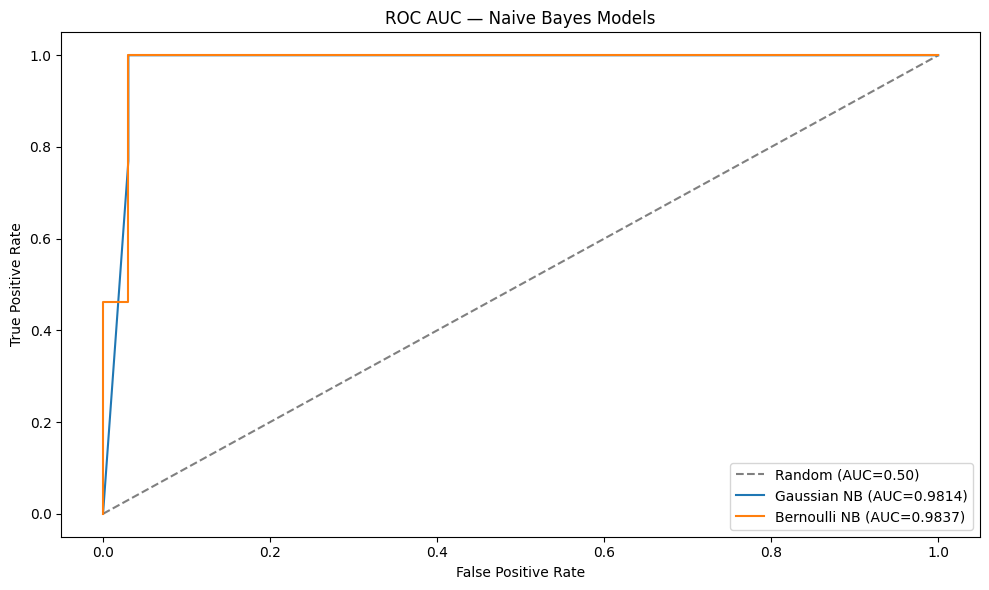

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC=0.50)")

gnb_fpr, gnb_tpr, _ = roc_curve(y_test, gnb_probs)
bnb_fpr, bnb_tpr, _ = roc_curve(y_test, bnb_probs)

ax.plot(gnb_fpr, gnb_tpr, label=f"Gaussian NB (AUC={gnb_auc:.4f})")
ax.plot(bnb_fpr, bnb_tpr, label=f"Bernoulli NB (AUC={bnb_auc:.4f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC AUC — Naive Bayes Models")
ax.legend()
plt.tight_layout()
plt.show()

___
# model Pickling
___

In [36]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/gaussian_nb.pkl", "wb") as f:
    pickle.dump(gnb, f)
print("✅ Gaussian NB saved")

with open("models/bernoulli_nb.pkl", "wb") as f:
    pickle.dump(bnb, f)
print("✅ Bernoulli NB saved")

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved")

with open("models/column_transformer.pkl", "wb") as f:
    pickle.dump(ct, f)
print("✅ ColumnTransformer saved")

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ LabelEncoder saved")

with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(all_cols, f)
print("✅ Feature columns saved")
print("Columns:", all_cols)

✅ Gaussian NB saved
✅ Bernoulli NB saved
✅ Scaler saved
✅ ColumnTransformer saved
✅ LabelEncoder saved
✅ Feature columns saved
Columns: ['sex_Male', 'smoker_Yes', 'day_Sat', 'day_Sun', 'day_Thur', 'total_bill', 'tip', 'size', 'tip_pct']
